# The director

A gynoid of 55 kg in MuJoCo, 27 joints each a drive; each millisecond a director picks the move that sets them - the arrival, the walk, a catch, the settling.

## 1 Setup

In [1]:
from coaxial import ExecutionMode

MODE = ExecutionMode.EMULATED   # the image on Renode, the stand-in where none runs; .HARDWARE and PORT at the bench
PORT = 'COM4'

## 2 The system

One pass a millisecond. The pose node reads her back - the pelvis placed and turned, the centre of mass, each sole's load - with every joint; the director hands the pass to one move; the move sets all 27 joints; each drive holds its setpoint with a PD of its own, as its board would, into the body.

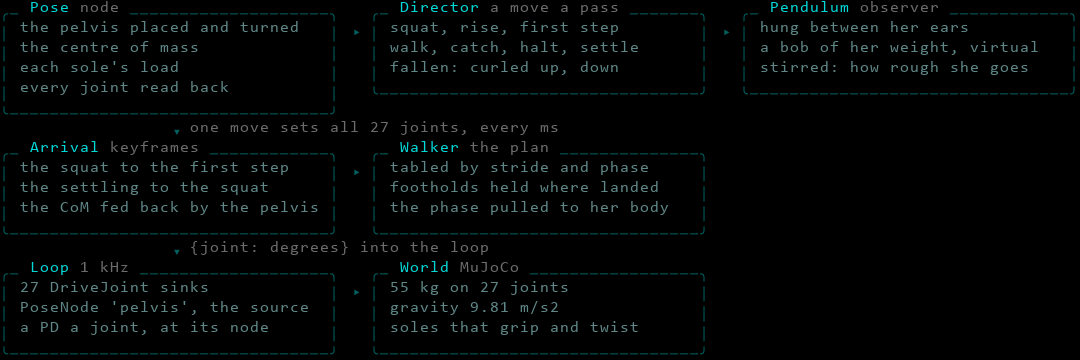

In [2]:
from machine import Machine, ansi
from machine.director import Director
from machine.modes import DYNAMIC
from machine.wiring import blocks

body = Machine.discover('gynoid', execution_mode=DYNAMIC)
body.arm()
world = body.nodes['pelvis'].world
director = Director(body, cadence=0.85)
ansi.image(blocks([
    ([('Pose', 'node', ['the pelvis placed and turned', 'the centre of mass',
                        "each sole's load", 'every joint read back']),
      ('Director', 'a move a pass', ['squat, rise, first step', 'walk, catch, halt, settle',
                                     'fallen: curled up, down']),
      ('Pendulum', 'observer', ['hung between her ears', 'a bob of her weight, virtual',
                                'stirred: how rough she goes'])],
     'one move sets all 27 joints, every ms'),
    ([('Arrival', 'keyframes', ['the squat to the first step', 'the settling to the squat',
                                'the CoM fed back by the pelvis']),
      ('Walker', 'the plan', ['tabled by stride and phase', 'footholds held where landed',
                              'the phase pulled to her body'])],
     '{joint: degrees} into the loop'),
    ([('Loop', '1 kHz', ['27 DriveJoint sinks', "PoseNode 'pelvis', the source",
                         'a PD a joint, at its node']),
      ('World', 'MuJoCo', ['55 kg on 27 joints', 'gravity 9.81 m/s2',
                           'soles that grip and twist'])], None)], width=34))

## 3 From the squat to the walk

`begin()` lands her in the squat; `step(dt)` each pass. The arrival's keyframes take her up and into a first step on her standing stance; the walker takes her on as that foot lands, the steps gliding into the catwalk. Every 10 ms kept: the stage, the pelvis, the soles, each drive's torque and power.

In [3]:
import numpy as np
import pandas
from machine.figure import JOINTS

director.begin()
body.loop.step(0.0)
bus = body.loop.bus
rows = []
while bus['t'] < 14.0:
    body.loop.write(**director.step(0.001))
    body.loop.step(0.001)
    if round(bus['t'] * 1000) % 10 == 0:
        d = world.data
        row = {'t': bus['t'], 'stage': director.stage, 'height': bus['pelvis.pose.y'],
               'on': bus['pelvis.pose.z'], 'left': bus['pelvis.pose.left_load'],
               'right': bus['pelvis.pose.right_load'], 'com_x': bus['pelvis.pose.com_x'],
               'com_y': bus['pelvis.pose.com_y'], 'com_z': bus['pelvis.pose.com_z']}
        row.update({j + ' Nm': abs(float(d.ctrl[i])) for i, j in enumerate(JOINTS)})
        row.update({j + ' W': float(d.ctrl[i] * d.qvel[world.vadr[i]])
                    for i, j in enumerate(JOINTS)})
        row.update({side + axis: ball[k] for side, ball in director.walker.balls.items()
                    for axis, k in (('_x', 0), ('_z', 2))})
        pend = director.pendulum
        row.update(swing_on=pend.swing[0], swing_across=pend.swing[1], felt=pend.felt,
                   stir=pend.stir, energy=pend.energy)
        rows.append(row)
run = pandas.DataFrame(rows).set_index('t')
began = run['stage'][run['stage'] != run['stage'].shift()]
print(began.to_string())

t
0.01    squat
1.51     look
2.31     push
3.31     rise
5.30    stand
6.30    shift
7.50     step
8.15     walk


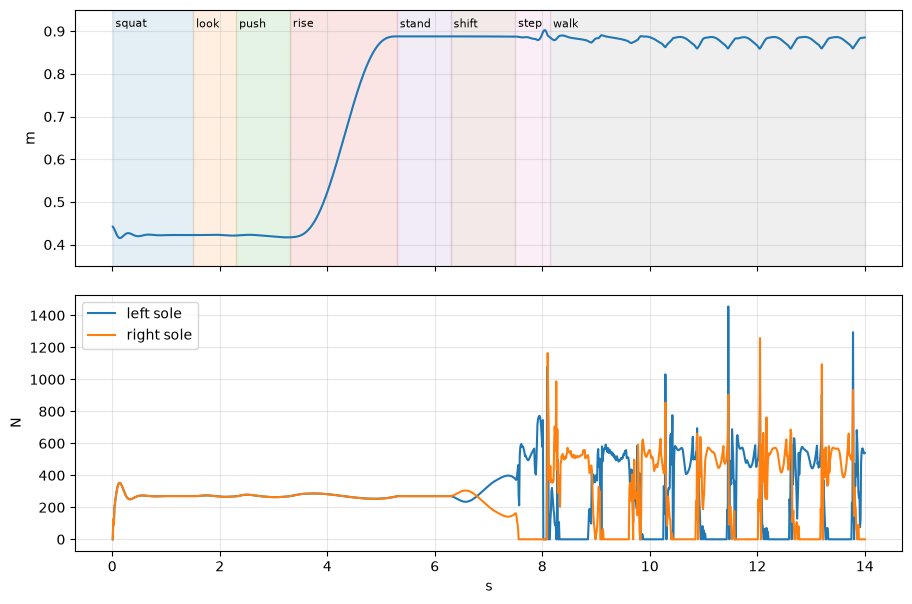

In [4]:
from coaxial.draw.figures import figure, show

fig, (top, bottom) = figure(rows=2, sharex=True)
for (t0, stage), t1 in zip(began.items(), list(began.index[1:]) + [run.index[-1]]):
    top.axvspan(t0, t1, alpha=0.12, color='C%d' % (list(began.values).index(stage) % 10))
    top.text(t0 + 0.05, 0.93, stage, fontsize=8, va='top')
top.plot(run.index, run['height'], label='pelvis over the floor')
top.set_ylabel('m')
top.set_ylim(0.35, 0.95)
bottom.plot(run.index, run['left'], label='left sole')
bottom.plot(run.index, run['right'], label='right sole')
bottom.set_ylabel('N')
bottom.set_xlabel('s')
bottom.legend(loc='upper left')
show(fig)

## 4 What each move asks of the drives

The strongest drives, stage by stage: the rms torque each held and the mean power each gave or braked - a feel for what a move costs. The squat and the rise are the knees' and the spine's; a landing's peak is its drives' limit for a millisecond, the PD against the floor.

In [5]:
STRONG = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle',
          'spine']
by = run.groupby('stage', sort=False)
held = by[[j + ' Nm' for j in STRONG]].agg(lambda x: float(np.sqrt((x ** 2).mean()))).round(0)
gave = by[[j + ' W' for j in STRONG]].agg(lambda w: float(w.abs().mean())).round(0)
print('rms torque, N m')
print(held.rename(columns=lambda c: c[:-3]).to_string())
print()
print('mean power, driving or braking, W')
print(gave.rename(columns=lambda c: c[:-2]).to_string())

rms torque, N m
       left_hip  left_knee  left_ankle  right_hip  right_knee  right_ankle  spine
stage                                                                            
squat      40.0       43.0        10.0       40.0        43.0         10.0   60.0
look       39.0       42.0         9.0       39.0        42.0          9.0   58.0
push       35.0       47.0         9.0       35.0        47.0          9.0   53.0
rise       20.0       45.0         9.0       20.0        45.0          9.0   32.0
stand       1.0       10.0         9.0        1.0        10.0          9.0    2.0
shift       2.0       12.0        11.0        1.0         9.0          8.0    2.0
step       73.0       59.0        50.0       74.0        58.0         22.0   22.0
walk       53.0       51.0        33.0       54.0        49.0         34.0   13.0

mean power, driving or braking, W
       left_hip  left_knee  left_ankle  right_hip  right_knee  right_ankle  spine
stage                                          

## 5 The plan

What the walker is told, a stride at a time (`machine.gait`, tabled in `machine.walker`): the foot lands on its heel, toes up 9 degrees, rolls flat, rises onto its ball; the stance knee near straight; the hips riding a smooth curve under what the stance legs reach.

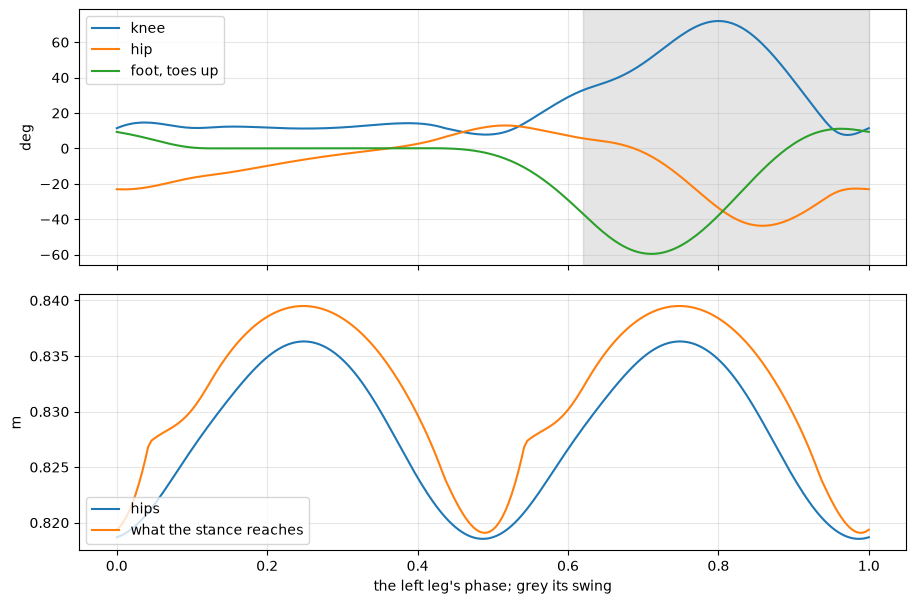

In [6]:
from machine import gait

phases = np.linspace(0.0, 1.0, 241)
plan = [gait.walk(0.0, stride=1.0, glance=False, phase=p) for p in phases]
fig, (top, bottom) = figure(rows=2, sharex=True)
top.plot(phases, [a['left_knee'] for a in plan], label='knee')
top.plot(phases, [a['left_hip'] for a in plan], label='hip')
top.plot(phases, [gait.pitch_of(p) for p in phases], label='foot, toes up')
top.axvspan(gait.TOE_OFF, 1.0, alpha=0.1, color='k')
top.set_ylabel('deg')
top.legend(loc='upper left')
bottom.plot(phases, [gait._hips(p, 1.0) for p in phases], label='hips')
bottom.plot(phases, [gait._limit(p, 1.0) for p in phases], label='what the stance reaches')
bottom.set_ylabel('m')
bottom.set_xlabel('the left leg\'s phase; grey its swing')
bottom.legend(loc='lower left')
show(fig)

## 6 The pendulum between her ears

How smoothly she goes, as one number: a virtual pendulum pivoted between her inner ears, a bob of her weight hung to her knees, moved by her head (`machine.pendulum`). Carried evenly it hangs still; her surge, sway and bob stir it. `stir` is its energy, as the height it would lift her.

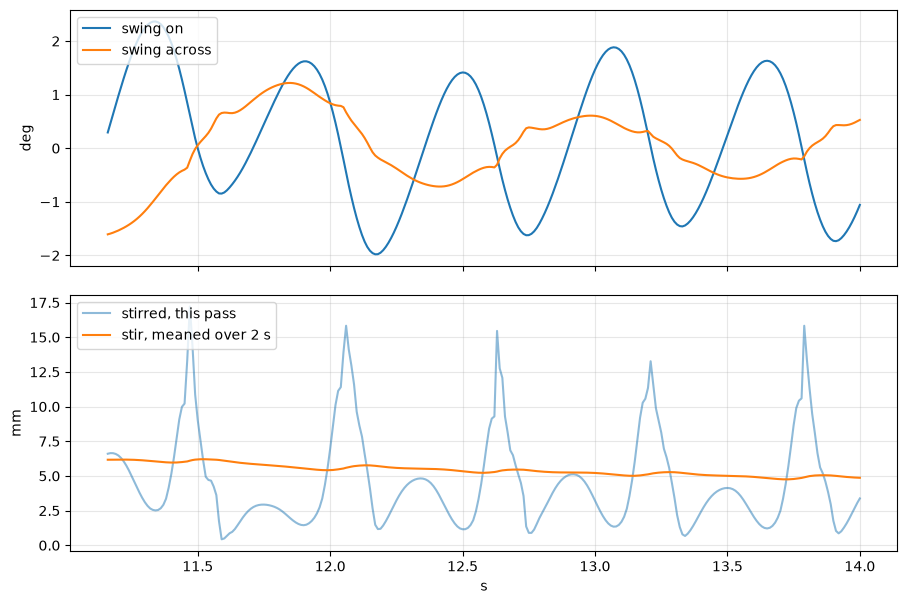

walking steadily: stir 4.52 mm, the string pulling 0.985..1.009 of her weight


In [7]:
walking = run[run['stage'].isin(['walk', 'catch'])]
steady = walking[walking.index > walking.index[0] + 3.0]
fig, (top, bottom) = figure(rows=2, sharex=True)
top.plot(steady.index, steady['swing_on'], label='swing on')
top.plot(steady.index, steady['swing_across'], label='swing across')
top.set_ylabel('deg')
top.legend(loc='upper left')
bottom.plot(steady.index, steady['energy'], alpha=0.5, label='stirred, this pass')
bottom.plot(steady.index, steady['stir'], label='stir, meaned over 2 s')
bottom.set_ylabel('mm')
bottom.set_xlabel('s')
bottom.legend(loc='upper left')
show(fig)
print('walking steadily: stir %.2f mm, the string pulling %.3f..%.3f of her weight'
      % (steady['energy'].mean(), steady['felt'].min(), steady['felt'].max()))

## 7 The walk, animated

Two seconds of her walk as the terminal draws her (`coaxial.graphics.gynoid`, in braille), 20 frames a second, played in the page.

In [8]:
from IPython.display import HTML
from matplotlib import animation, pyplot
from coaxial.graphics import gynoid
from machine.figure import quat

frames, follow = [], gynoid.Follow()
until = bus['t'] + 2.0
while bus['t'] < until:
    body.loop.write(**director.step(0.001))
    body.loop.step(0.001)
    if round(bus['t'] * 1000) % 50 == 0:
        angles = {j: bus[j + '.deg'] for j in JOINTS}
        turn = quat(bus['pelvis.pose.qw'], bus['pelvis.pose.qx'], bus['pelvis.pose.qy'],
                    bus['pelvis.pose.qz'])
        z = bus['pelvis.pose.z']
        camera = follow(z, bus['pelvis.pose.vz'], bus['t'])
        lines = gynoid.render(angles, 56, 24, yaw=60.0, colour=False, travel=camera,
                              root=((bus['pelvis.pose.x'], bus['pelvis.pose.y'], z - camera),
                                    turn))
        frames.append(np.asarray(ansi.image('\n'.join(lines), cell=(6, 12))))
fig, (axis,) = figure(rows=1)
axis.axis('off')
shown = axis.imshow(frames[0])
film = animation.FuncAnimation(fig, lambda i: [shown.set_data(frames[i])],
                               frames=len(frames), interval=50)
pyplot.close(fig)
HTML(film.to_jshtml(default_mode='loop'))

## 8 Live

Her own process, paced to the wall clock (`machine.running`): landed in the squat, rising - the cell redraws her as she goes, 10 frames a second for 12 s. The terminal page is the same body at 30: `terminal/views/show_humanoid.py`.

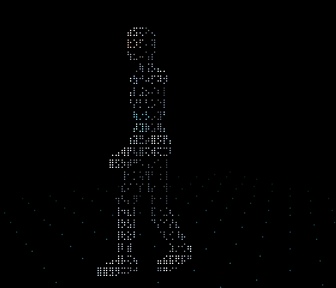

walk at 9.7 s


In [9]:
import time
from IPython.display import display
from machine.running import Running

live, follow = Running(cadence=0.85), gynoid.Follow()
view = display(None, display_id=True)
until = time.time() + 12.0
try:
    while time.time() < until:
        now = live.latest()
        if now is not None:
            x, y, z = now['where']
            camera = follow(z, now['speed'], now['t'])
            lines = gynoid.render(now['angles'], 56, 24, yaw=60.0, travel=camera,
                                  root=((x, y, z - camera), quat(*now['turn'])))
            view.update(ansi.image('\n'.join(lines), cell=(6, 12)))
        time.sleep(0.1)
finally:
    live.close()
print(now['stage'], 'at %.1f s' % now['t'])

## 9 Results

From the squat she rises, steps off and walks on at 0.85 strides/s; the walk is the finest of 576 judged by the straight stance knee, the landing, the head and the copper (`docs/FINDINGS.md`, 2026-09-26). The start holds at that pace only and the stop runs on over the front foot: the pendulum's capture point is the next step (`docs/TODO.md`).

**Bench.** No board: every drive is simulated, a PD at 1 kHz into MuJoCo. On the bench the same setpoints go to the boards over their buses; the pose comes from the IMU and the soles' loads.

## References

* `machine/director.py` - which move has her, catches, falls
* `machine/arrival.py` - the keyframes: the squat, the rise, the first step, the settling
* `machine/walker.py` - the walk: plan, footholds, phase, balance
* `machine/gait.py` - the plan: the stride, the foot's roll, the hips
* `machine/physics.py` - the body in MuJoCo, a drive a joint
* `machine/running.py` - her own process, paced to the clock
* `terminal/views/show_humanoid.py` - the terminal page